<img src="https://www.funcionpublica.gov.co/documents/d/guest/logo-universidad-nacional" alt="Logo UNAL" width="600"/>

### **Universidad Nacional de Colombia sede Manizales**
#### Facultad de ingeniería y arquitectura
#### Departamento de ingeniería eléctrica, electrónica y computación
#### *Procesamiento del Lenguaje Natural*

#### Profesor: Lucas Iturriago
#### Monitora: Isabella Valero Mora - lvalerom@unal.edu.co

# 1. El Problema del Cuello de Botella: De la Memoria al Enfoque

## 2. ¿Por qué fallan las RNN y LSTM en secuencias largas?

Durante años, las Redes Neuronales Recurrentes (RNN) y sus variantes como las **LSTM (Long Short-Term Memory)** fueron el estado del arte. Sin embargo, presentan dos limitaciones críticas que impiden su escalabilidad en tareas de procesamiento de lenguaje natural (NLP) moderno:

1.  **El Gradiente Desvanecido:** A pesar de las compuertas de las LSTM, al procesar secuencias de cientos de palabras, la señal del error se diluye. El modelo "olvida" el inicio de la oración cuando llega al final.
2.  **La Compresión de Información (El Cuello de Botella):** Las arquitecturas *Encoder-Decoder* tradicionales intentan comprimir **toda** la semántica de una oración de entrada en un único vector de tamaño fijo (llamado *context vector* o estado oculto final).

> **Analogía:** Imagina que lees un libro de 300 páginas y, al terminar, alguien te pide que resumas cada detalle importante usando solo una frase de 10 palabras. Es inevitable que se pierda información vital.

## 3. La Intuición de la Atención: "Fijarse en lo importante"

El mecanismo de atención surge como una solución a este cuello de botella. En lugar de intentar recordar todo de forma secuencial, el modelo decide **en qué partes de la entrada debe enfocarse** para generar cada palabra de la salida.

Inspirado en la visión humana:
* Cuando observas una fotografía de un bosque, tus ojos no procesan cada píxel con la misma intensidad.
* Tu sistema visual hace un "escaneo" y se enfoca en los elementos relevantes (un animal entre los árboles, un camino, etc.), dejando el resto en una resolución periférica.

En términos de ingeniería de datos, la atención permite que cada posición en la secuencia tenga un **acceso directo** a todas las demás posiciones, eliminando la dependencia de una "memoria lineal" y permitiendo que el modelo aprenda relaciones globales, sin importar la distancia entre palabras.



In [1]:
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

In [2]:
# Ejemplo conceptual: Visualización de pesos de atención (Simulado)

def plot_attention_intuition():
    words = ["El", "modelo", "aprendió", "el", "contexto", "rápidamente"]
    # Simulación de una matriz donde la palabra "contexto" tiene más peso sobre "modelo" y "aprendió"
    attention_map = np.random.rand(6, 6)
    attention_map[4, 1:3] += 1.5 # Resaltamos la relación

    plt.figure(figsize=(8, 6))
    plt.imshow(attention_map, cmap='viridis')
    plt.xticks(range(6), words, rotation=45)
    plt.yticks(range(6), words)
    plt.title("Intuición: ¿A qué palabras 'presta atención' el modelo?")
    plt.colorbar(label="Intensidad de Atención")
    plt.tight_layout()
    plt.show()

# plot_attention_intuition() # Ejecutar en el notebook para visualizar la analogía

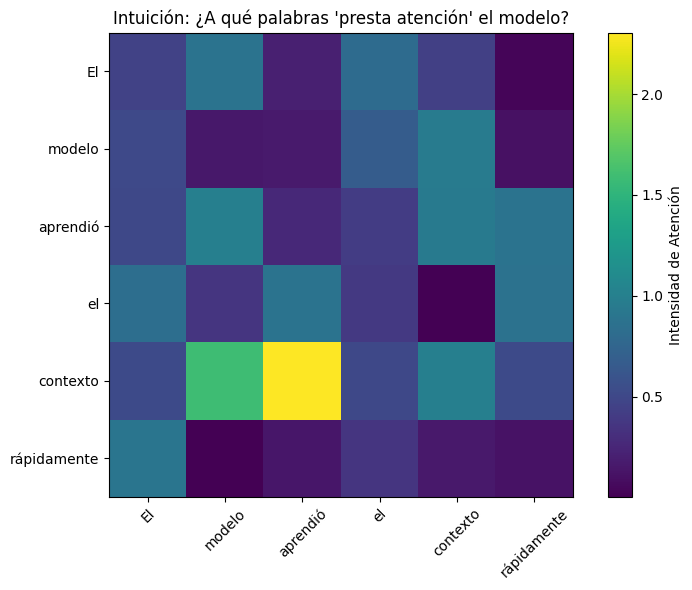

In [3]:
plot_attention_intuition()

# 1. El Mecanismo de "Scaled Dot-Product Attention"

Una vez comprendida la necesidad de un enfoque selectivo, debemos formalizar cómo una máquina puede "decidir" qué es importante. El Transformer utiliza un sistema de **recuperación de información** basado en tres vectores fundamentales.

## 2. Los Tres Actores: Query, Key y Value

Para entender estos conceptos, podemos usar la analogía de un **motor de búsqueda** o una base de datos:

* **Query ($Q$):** Es lo que "estoy buscando". Representa la palabra actual que intenta entender su contexto.
* **Key ($K$):** Es la "etiqueta" o el índice de lo que cada palabra en la secuencia ofrece. Se compara con la Query para determinar la relevancia.
* **Value ($V$):** Es la "información" o el contenido semántico. Si hay una coincidencia entre la Query y la Key, extraemos esta información.


## 3. La Ecuación Maestra

El cálculo de la atención se resume en la siguiente expresión matemática, la cual es el núcleo de todo el modelo:

$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Desglose del proceso:**
1.  **Puntuación ($QK^T$):** Realizamos un producto punto entre la consulta y todas las llaves. Esto mide la similitud (afinidad) entre palabras.
2.  **Escalamiento ($\frac{1}{\sqrt{d_k}}$):** Dividimos por la raíz cuadrada de la dimensión de las llaves ($d_k$).
3.  **Normalización (Softmax):** Convertimos las puntuaciones en probabilidades que suman 1. Las palabras irrelevantes se acercan a 0 y las importantes a 1.
4.  **Agregación ($\dots V$):** Multiplicamos estas probabilidades por los valores. El resultado es un vector que contiene la información de los valores, ponderada por su relevancia respecto a la Query.

## 4. ¿Por qué escalar con $\sqrt{d_k}$?

Esta es una decisión de ingeniería crucial. Cuando la dimensión $d_k$ es muy grande, los productos punto tienden a crecer en magnitud.

Si los valores que entran al **softmax** son muy grandes, la función se satura en regiones donde el gradiente es extremadamente pequeño (casi cero). Esto causaría el mismo problema que queríamos evitar: dificultades en el entrenamiento por **gradientes desvanecidos**. El factor $\sqrt{d_k}$ mantiene la varianza de los productos punto cerca de 1, asegurando estabilidad numérica.

In [4]:
def scaled_dot_product_attention(q, k, v):
    """
    Implementación funcional de la atención escalada.
    Args:
        q, k, v: Tensores de forma (batch, heads, seq_len, d_k)
    """
    d_k = q.size(-1)

    # 1. Producto punto Q y K (transponiendo las últimas dos dimensiones de K)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

    # 2. Aplicar Softmax para obtener los pesos (Attention Weights)
    weights = F.softmax(scores, dim=-1)

    # 3. Multiplicar pesos por los Valores
    output = torch.matmul(weights, v)

    return output, weights

# Ejemplo rápido:
# 1 secuencia de 4 palabras, cada una con dimensión 8
q_example = torch.rand(1, 1, 4, 8)
k_example = torch.rand(1, 1, 4, 8)
v_example = torch.rand(1, 1, 4, 8)

output, attn_weights = scaled_dot_product_attention(q_example, k_example, v_example)
print(f"Forma del output: {output.shape}")
print(f"Pesos de atención (ejemplo primera palabra):\n{attn_weights[0, 0, 0, :]}")

Forma del output: torch.Size([1, 1, 4, 8])
Pesos de atención (ejemplo primera palabra):
tensor([0.2471, 0.1880, 0.2239, 0.3410])


# 1. Multi-Head Attention (MHA): Paralelismo de Enfoques

## 2. ¿Por qué múltiples cabezas?
Si utilizáramos una sola función de atención sobre toda la dimensión del modelo ($d_{model}$), estaríamos limitando la capacidad de la red para extraer información simultánea de diferentes subespacios de representación.

**La Intuición:**
En ingeniería, a menudo analizamos una señal desde diferentes dominios (tiempo, frecuencia, fase). De manera similar, el Multi-Head Attention permite que el modelo "mire" la misma secuencia con diferentes propósitos:
* Una cabeza puede enfocarse en la **estructura sintáctica** (¿quién realizó la acción?).
* Otra cabeza puede detectar **relaciones semánticas** (¿qué sentimientos evoca este adjetivo?).
* Una tercera puede especializarse en **referencias de largo alcance** (¿a qué sustantivo se refiere este pronombre lejano?).



## 3. Concatenación y Proyección
Formalmente, en lugar de realizar una sola operación de atención, proyectamos $Q, K$ y $V$ de forma independiente $h$ veces (donde $h$ es el número de cabezas). Cada resultado se conoce como una "cabeza" ($head_i$):

$$head_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

Donde $W_i^Q, W_i^K, W_i^V$ son matrices de parámetros aprendibles. Finalmente, concatenamos los resultados de todas las cabezas y aplicamos una transformación lineal final ($W^O$):

$$MultiHead(Q, K, V) = \text{Concat}(head_1, \dots, head_h)W^O$$

Este paso de proyección final permite que la red combine la información de todas las cabezas de manera que sea útil para las capas posteriores.

In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model debe ser divisible por num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads # Dimensión por cada cabeza

        # Definición de las proyecciones lineales (Pesos W)
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)

        # Proyección final después de concatenar
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        # 1. Proyecciones lineales y división en h cabezas
        # Formato: (batch, seq_len, d_model) -> (batch, num_heads, seq_len, d_k)
        q = self.w_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        k = self.w_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        v = self.w_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # 2. Scaled Dot-Product Attention (visto en la Sección 2)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = torch.softmax(scores, dim=-1)
        context = torch.matmul(attn_weights, v) # (batch, num_heads, seq_len, d_k)

        # 3. Concatenación: Volvemos a la dimensión original d_model
        # Transpose + contiguous es necesario antes de cambiar la vista (view)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        # 4. Proyección lineal final
        return self.w_o(context)

# Demostración técnica para los estudiantes
d_model = 512
heads = 8
mha_layer = MultiHeadAttention(d_model, heads)

# Supongamos una secuencia de 10 palabras (tokens)
x = torch.randn(1, 10, d_model)
output = mha_layer(x, x, x)

print(f"Dimensiones de entrada: {x.shape}")
print(f"Dimensiones de salida:  {output.shape}")

Dimensiones de entrada: torch.Size([1, 10, 512])
Dimensiones de salida:  torch.Size([1, 10, 512])


# 1. Codificación Posicional (Positional Encoding)

## 2. El Problema: La Pérdida del Orden
A diferencia de las RNN, que procesan la información paso a paso (secuencialmente), el Transformer procesa toda la secuencia de entrada en paralelo. Si bien esto permite una velocidad de entrenamiento masiva, introduce un problema crítico: **el modelo es "invariante a la permutación"**.

Para un Transformer, la oración *"El perro muerde al hombre"* y *"El hombre muerde al perro"* son idénticas si solo consideramos el conjunto de vectores de palabras. No hay una noción intrínseca de quién va primero.



## 3. La Solución: Ondas para Representar el Tiempo
Para solucionar esto, inyectamos información sobre la posición de cada palabra directamente en los *embeddings*. En lugar de usar un simple índice (1, 2, 3...), lo cual podría generar valores muy grandes que desestabilicen la red, los autores del paper original propusieron el uso de funciones sinusoidales de diferentes frecuencias:

$$PE_{(pos, 2i)} = \sin(pos / 10000^{2i/d_{model}})$$
$$PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i/d_{model}})$$

Donde:
* **$pos$**: Es la posición de la palabra en la oración.
* **$i$**: Es la dimensión dentro del vector de embedding.
* **$d_{model}$**: Es la dimensión total del modelo.

**¿Por qué esta función?**
1.  **Valores acotados:** Los resultados siempre están entre -1 y 1.
2.  **Relaciones relativas:** Para cualquier desfase fijo $k$, $PE_{pos+k}$ puede representarse como una función lineal de $PE_{pos}$. Esto permite que el modelo aprenda a atender por distancias relativas fácilmente.
3.  **Extrapolación:** Permite al modelo, teóricamente, manejar secuencias más largas de las que vio durante el entrenamiento.



In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()

        # Crear una matriz de ceros para las posiciones
        pe = torch.zeros(max_len, d_model)

        # Vector de posiciones (0, 1, 2, ..., max_len-1)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # Término de división basado en la dimensión (el denominador de la fórmula)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        # Aplicar seno a los índices pares e coseno a los impares
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Añadir una dimensión de batch y registrar como buffer (no es un parámetro entrenable)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        # Sumamos el encoding a los embeddings de entrada
        x = x + self.pe[:, :x.size(1), :]
        return x

## Visualización del "Mapa de Posiciones"
Para que los estudiantes comprendan la estructura, visualizaremos la matriz de codificación posicional. Cada fila representa una posición y cada columna una dimensión del embedding.

In [7]:
def plot_pe():
    d_model = 128
    max_len = 50
    pe_layer = PositionalEncoding(d_model, max_len)
    pe_matrix = pe_layer.pe.squeeze(0).cpu().numpy()

    plt.figure(figsize=(10, 6))
    plt.pcolormesh(pe_matrix, cmap='RdBu')
    plt.xlabel('Dimensión del Embedding ($d_{model}$)')
    plt.ylabel('Posición del Token ($pos$)')
    plt.title("Matriz de Positional Encoding")
    plt.colorbar(label="Valor de la función sin/cos")
    plt.show()

# plot_pe() # Ejecutar para ver el patrón de interferencia que permite al modelo "medir" distancias

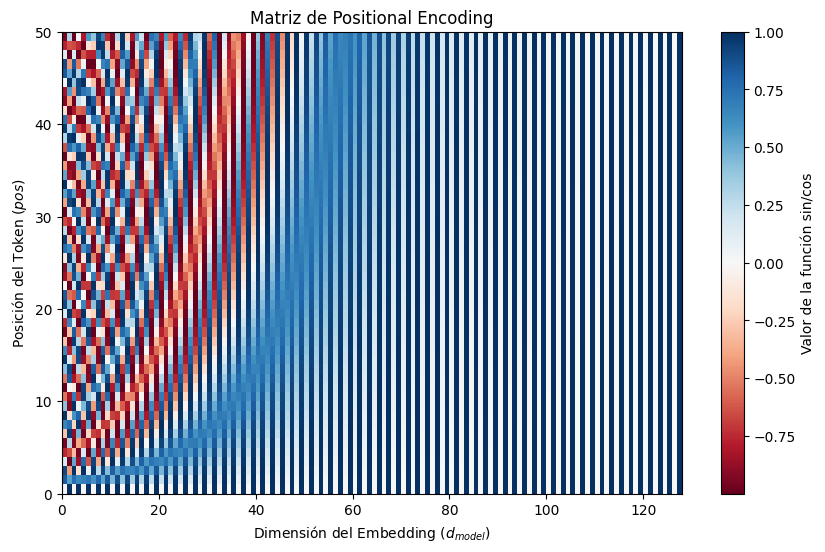

In [8]:
plot_pe()

# 1. El Bloque Transformer (Encoder)

Hasta ahora hemos analizado los componentes individuales (Atención, Positional Encoding). El **Encoder** es la estructura que orquesta estos elementos para transformar una secuencia de entrada en una representación rica en contexto. Un Transformer no es una sola capa, sino un "stack" o pila de varios de estos bloques idénticos.

## 2. Normalización y Conexiones Residuales (Add & Norm)

En redes neuronales muy profundas, el entrenamiento se vuelve inestable debido a que la información se degrada al pasar por muchas capas. El Transformer soluciona esto mediante dos mecanismos que actúan como "estabilizadores de señal":

1.  **Conexiones Residuales (Skip Connections):** En lugar de que la salida de una subcapa sea simplemente $f(x)$, la salida es $x + f(x)$. Esto permite que el gradiente fluya directamente a través de la red durante el *backpropagation*, mitigando el desvanecimiento del gradiente.
2.  **Layer Normalization:** A diferencia de la normalización por lote (Batch Norm), la **Layer Norm** normaliza las activaciones a través de las características para cada ejemplo individualmente. Esto asegura que los valores de entrada a la siguiente capa tengan una media y varianza controladas, acelerando la convergencia.

La operación completa se define como:
$$Output = \text{LayerNorm}(x + \text{Sublayer}(x))$$



---

## 3. Redes Feed-Forward de Posición (Point-wise FFN)

Después de la capa de atención, cada bloque incluye una red neuronal densa (MLP) que se aplica a cada posición de la secuencia de forma **independiente e idéntica**.

Consta de dos transformaciones lineales con una activación ReLU entre ellas:
$$FFN(x) = \max(0, xW_1 + b_1)W_2 + b_2$$

**¿Por qué es necesaria?** Mientras que la atención permite que las palabras interactúen entre sí para capturar el contexto global, la FFN permite que cada token procese esa información de contexto y actualice su propia representación interna de forma individual. Es el espacio donde el modelo "reflexiona" sobre lo que aprendió en el paso de atención.



In [9]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(TransformerBlock, self).__init__()

        # Componente de Atención
        self.attention = MultiHeadAttention(d_model, num_heads)

        # Componente Feed-Forward
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )

        # Capas de Normalización
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        # Dropout para regularización
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # 1. Subcapa de Atención + Conexión Residual + Norm
        attn_output = self.attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))

        # 2. Subcapa Feed-Forward + Conexión Residual + Norm
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))

        return x

# Ejemplo de uso:
d_model = 512
heads = 8
d_ff = 2048 # Dimensión oculta de la FFN (usualmente 4x d_model)

block = TransformerBlock(d_model, heads, d_ff)
input_tensor = torch.randn(1, 10, d_model) # (Batch, Seq, Dim)
output = block(input_tensor)

print(f"Entrada al bloque: {input_tensor.shape}")
print(f"Salida del bloque:  {output.shape}")

Entrada al bloque: torch.Size([1, 10, 512])
Salida del bloque:  torch.Size([1, 10, 512])


# 1. Implementación en PyTorch: Construcción Modular y Herramientas Nativas

En esta sección, ensamblaremos todas las piezas desarrolladas anteriormente para construir el **Transformer Encoder** completo. Además, discutiremos cuándo es conveniente usar implementaciones manuales y cuándo debemos confiar en las herramientas optimizadas de PyTorch.

## 2. Clase TransformerEncoder: El Ensamblaje Final

El Encoder completo recibe una secuencia de índices (tokens), los convierte en vectores densos (embeddings), les inyecta la noción de orden (positional encoding) y los procesa a través de $N$ bloques de Transformer.



In [10]:
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, max_len=5000, dropout=0.1):
        super(TransformerEncoder, self).__init__()

        # 1. Capa de Embedding: Convierte índices de palabras en vectores
        self.embedding = nn.Embedding(vocab_size, d_model)

        # 2. Codificación Posicional (Clase definida en la Sección 4)
        self.pos_encoding = PositionalEncoding(d_model, max_len)

        # 3. Pila de Bloques Transformer (Clase definida en la Sección 5)
        # Usamos nn.ModuleList para que PyTorch rastree correctamente los parámetros
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # x shape: (batch_size, seq_len)

        # Pasar de índices a embeddings y sumar posición
        x = self.dropout(self.pos_encoding(self.embedding(x)))

        # Pasar por cada bloque secuencialmente
        for layer in self.layers:
            x = layer(x, mask)

        return x

## 3. Implementación Manual vs. Herramientas Optimizadas (`nn.MultiheadAttention`)

Para propósitos académicos, entender la implementación manual es fundamental para diagnosticar problemas y proponer arquitecturas personalizadas. Sin embargo, en entornos de producción o investigación de alto rendimiento, PyTorch ofrece `nn.MultiheadAttention` y `nn.TransformerEncoderLayer`.

**¿Por qué preferir la versión nativa?**

* **Optimizaciones a bajo nivel:** PyTorch utiliza kernels de C++ y CUDA altamente optimizados (como **FlashAttention**), que reducen drásticamente el consumo de memoria y el tiempo de cómputo.
* **Estabilidad Numérica:** Las implementaciones nativas manejan casos de borde y precisiones (FP16/BF16) de forma más robusta.
* **Facilidad de Mantenimiento:** Menos código propio significa menos bugs potenciales.

| Característica | Implementación Manual (Nuestra) | PyTorch Native (`nn.Module`) |
| :--- | :--- | :--- |
| **Claridad Pedagógica** | Alta: Se ve cada operación | Baja: Caja negra |
| **Velocidad (Training)** | Estándar | Muy Alta (C++ Kernels) |
| **Personalización** | Total (podemos cambiar el Softmax) | Limitada a parámetros expuestos |
| **Eficiencia de Memoria** | $O(n^2)$ | Optimizada (FlashAttention) |

In [11]:
# Ejemplo: Cómo usar la versión optimizada de PyTorch
# d_model=512, nhead=8
native_mha = nn.MultiheadAttention(embed_dim=512, num_heads=8, batch_first=True)

# La versión nativa devuelve (output, weights)
input_tensor = torch.randn(1, 10, 512)
output, attn_weights = native_mha(input_tensor, input_tensor, input_tensor)

print(f"Salida optimizada: {output.shape}")
print(f"Mapa de atención generado: {attn_weights.shape}")

Salida optimizada: torch.Size([1, 10, 512])
Mapa de atención generado: torch.Size([1, 10, 10])


#  Ejercicio Final: Clasificación Real y Visualización de Atención (XAI)

Para que este ejercicio sea genuino, redefiniremos nuestro modelo para que sea "transparente", es decir, que nos permita extraer la matriz de atención de la última capa. Entrenaremos el modelo con una porción del dataset IMDb para que aprenda a reconocer palabras clave.

## Redefinición del Modelo para Extracción de Pesos
> *Nota: Modificamos el `forward` de las clases para que retornen los pesos de atención.*

In [32]:
class MultiHeadAttentionTransparent(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)
        q = self.w_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        k = self.w_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        v = self.w_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Cálculo de Scores
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        # Guardamos los pesos de atención
        attn_weights = torch.softmax(scores, dim=-1)
        output = torch.matmul(attn_weights, v)
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.num_heads * self.d_k)

        return self.w_o(output), attn_weights # Retornamos los pesos reales

class TransformerBlockTransparent(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttentionTransparent(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out, weights = self.attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x, weights # Pasamos los pesos hacia arriba

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len=128)
        self.layers = nn.ModuleList([TransformerBlockTransparent(d_model, num_heads, d_model*4) for _ in range(num_layers)])
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x, mask=None):
        x = self.pos_encoding(self.embedding(x))
        last_weights = None
        for layer in self.layers:
            x, last_weights = layer(x, mask)

        # Tomamos el promedio (Pooling) para clasificar
        pooled = torch.mean(x, dim=1)
        return self.classifier(pooled), last_weights

## Entrenamiento Breve con IMDb
Para que el heatmap no sea ruido, el modelo debe "aprender" a ignorar el padding y enfocarse en palabras clave.

In [33]:
# 1. Cargar subconjunto pequeño para rapidez (2 epochs en 2000 ejemplos)
dataset = load_dataset("imdb", split={'train': 'train[:2000]', 'test': 'test[:500]'})
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_fn(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_data = dataset.map(tokenize_fn, batched=True)
tokenized_data.set_format(type='torch', columns=['input_ids', 'label'])
train_loader = DataLoader(tokenized_data['train'], batch_size=16, shuffle=True)

# 2. Configurar Entrenamiento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerClassifier(tokenizer.vocab_size, d_model=128, num_heads=4, num_layers=2, num_classes=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# 3. Entrenamiento rápido (XAI requiere que el modelo sepa qué está haciendo)
model.train()
print("Entrenando modelo para ajustar pesos de atención...")
for epoch in range(2): # 2 épocas son suficientes para ver patrones de atención
    for batch in train_loader:
        optimizer.zero_grad()
        ids = batch['input_ids'].to(device)
        mask = (ids != tokenizer.pad_token_id).unsqueeze(1).unsqueeze(2) # Padding Mask real
        labels = batch['label'].to(device)

        logits, _ = model(ids, mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
    print(f"Época {epoch+1} completada.")

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Entrenando modelo para ajustar pesos de atención...
Época 1 completada.
Época 2 completada.


## 7.3 Visualización XAI
Ahora extraeremos la matriz de atención **auténtica** del modelo entrenado.

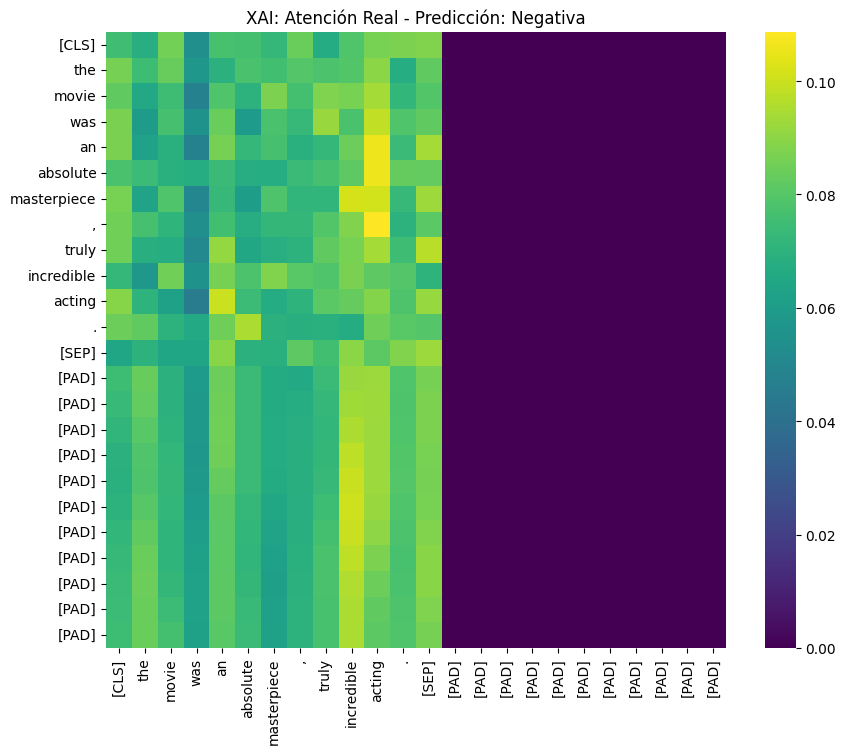

In [34]:
def plot_real_attention(model, sentence, tokenizer, device):
    model.eval()
    inputs = tokenizer(sentence, return_tensors="pt", padding="max_length", truncation=True, max_length=24).to(device)
    ids = inputs['input_ids']
    mask = (ids != tokenizer.pad_token_id).unsqueeze(1).unsqueeze(2)

    with torch.no_grad():
        logits, attn_weights = model(ids, mask)
        prediction = torch.argmax(logits, dim=-1).item()

    # attn_weights shape: (batch, heads, seq_len, seq_len)
    # Promediamos las cabezas de atención para ver el enfoque global
    avg_attention = attn_weights[0].mean(dim=0).cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(ids[0])

    plt.figure(figsize=(10, 8))
    sns.heatmap(avg_attention, xticklabels=tokens, yticklabels=tokens, cmap='viridis')
    plt.title(f"XAI: Atención Real - Predicción: {'Positiva' if prediction == 1 else 'Negativa'}")
    plt.show()

# Probamos con una frase cargada de sentimiento
test_sentence = "The movie was an absolute masterpiece, truly incredible acting."
plot_real_attention(model, test_sentence, tokenizer, device)